In [1]:
import os
import joblib
import pandas as pd
from tqdm import tqdm

from lime.lime_tabular import LimeTabularExplainer
from dotenv import load_dotenv
from xgboost import XGBClassifier

load_dotenv()
os.chdir("..")

MODELDIR = os.getenv("MODELDIR")
DATADIR = os.getenv("DATADIR")

xgb = XGBClassifier()
xgb.load_model(f"{MODELDIR}/xgb_model.ubj")
X_test, y_test = joblib.load(f"{DATADIR}/test_data.pkl")
X_train_bal, y_train_bal = joblib.load(f"{DATADIR}/train_data.pkl")

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(X_test.shape)

(294, 44)


In [2]:
explainer = LimeTabularExplainer(
    training_data=X_train_bal.values,
    feature_names=X_train_bal.columns.tolist(),
    class_names=["Stayed", "Left"],
    mode="classification",
    random_state=42,
    discretize_continuous=False,
)


In [3]:
lime_weights = []

for i in tqdm(range(len(X_test))):
    exp = explainer.explain_instance(
        data_row=X_test.values[i],
        predict_fn=xgb.predict_proba,
        num_features=len(X_train_bal.columns),
        num_samples=1000,
    )
    weights = dict(exp.as_list())
    lime_weights.append(weights)

lime_weights_df = pd.DataFrame(lime_weights).fillna(0)

lime_global = lime_weights_df.abs().mean().sort_values(ascending=False)
print(lime_global.head(10))

100%|██████████| 294/294 [00:04<00:00, 71.69it/s]

Department_Research & Development    0.038350
StockOptionLevel                     0.035804
EnvironmentSatisfaction              0.027771
JobSatisfaction                      0.019944
DistanceFromHome                     0.015390
NumCompaniesWorked                   0.014704
JobLevel                             0.014368
WorkLifeBalance                      0.013974
MonthlyIncome                        0.013478
YearsWithCurrManager                 0.012885
dtype: float64


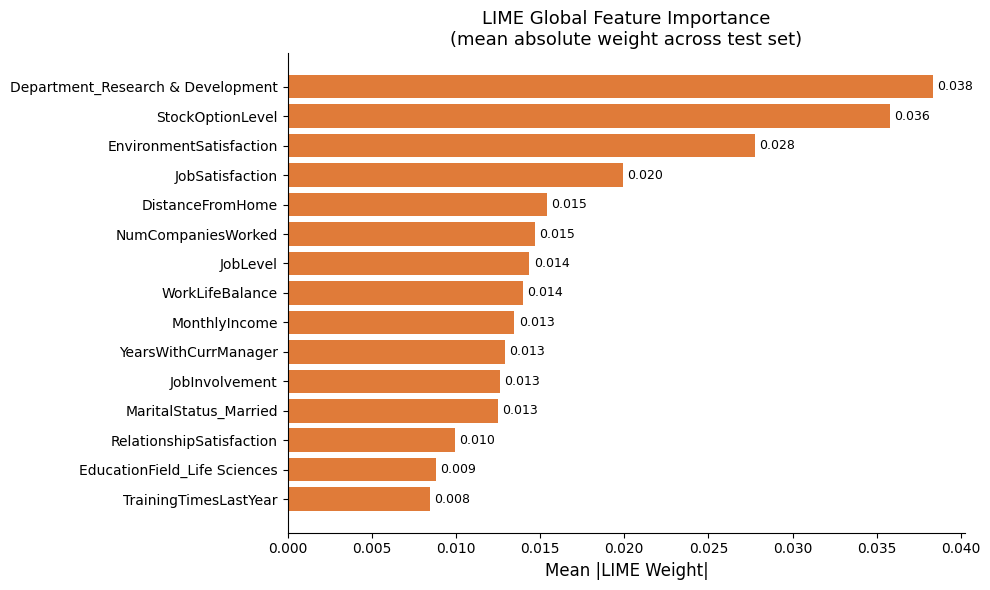

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

top_n = 15
lime_global_top = lime_global.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    y=lime_global_top.index[::-1],
    width=lime_global_top.values[::-1],
    color="#E07B39",
)

ax.set_xlabel("Mean |LIME Weight|", fontsize=12)
ax.set_title("LIME Global Feature Importance\n(mean absolute weight across test set)", fontsize=13)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

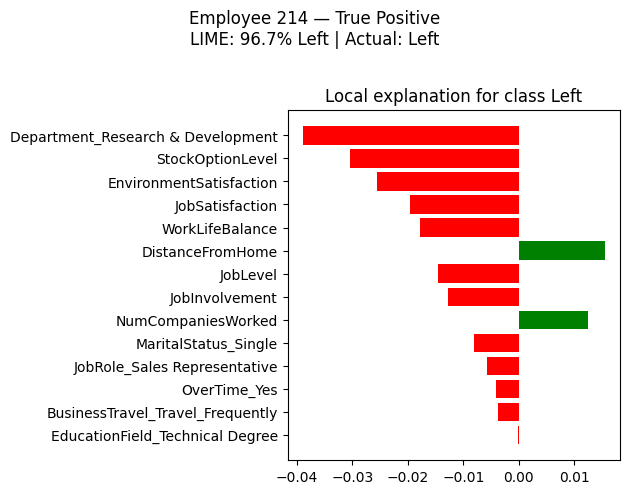

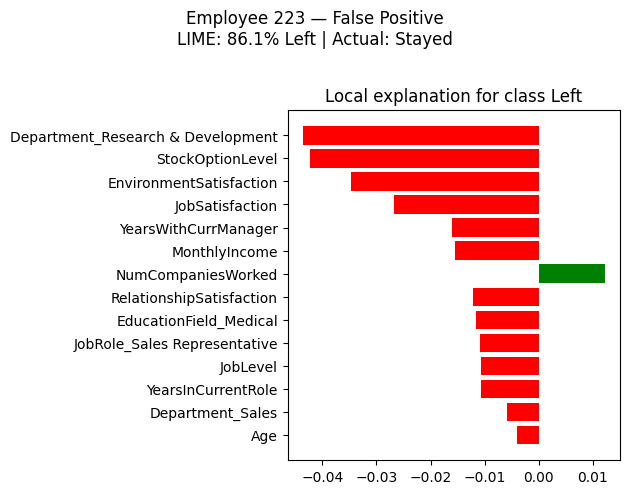

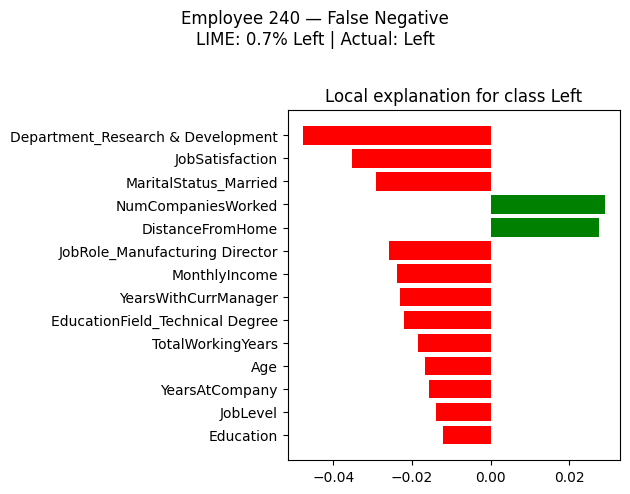

In [5]:
case_studies = [
    {"idx": 214, "label": "True Positive",  "predicted": "Left",   "actual": "Left"},
    {"idx": 223, "label": "False Positive", "predicted": "Left",   "actual": "Stayed"},
    {"idx": 240, "label": "False Negative", "predicted": "Stayed", "actual": "Left"},
]

for case in case_studies:
    idx = case["idx"]

    exp = explainer.explain_instance(
        data_row=X_test.values[idx],
        predict_fn=xgb.predict_proba,
        num_features=14,
        num_samples=1000,
    )

    prob_stayed, prob_left = exp.predict_proba

    fig = exp.as_pyplot_figure(label=1)   # label=1 = "Left" class
    fig.suptitle(
        f"Employee {idx} — {case['label']}\n"
        f"LIME: {prob_left:.1%} Left | Actual: {case['actual']}",
        fontsize=12,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()